## Parabola example
This example is designed to evaluate the accuracy of our membrane force calculation using the coordinates of a parabolic function. Specifically, it examines how well the original force distribution can be recovered when small noise is added to the initial coordinates. The process is outlined as follows:

1. Sample `N_node` coordinate from the parabola function, $y = h x^2$. Add Gaussian noise, $\mathcal{N}(0, \sigma_\mathrm{noise})$, to every sampled point in both $x$ and $y$ directions. 
2. Based on the sampled points, interpolate the curve using B-spline function. Resample `n_vertices` points evenly from the interpolated curve. The interpolation is done by minimizing the following objective function, $J = \sum^N (y_i - S(x_i))^2 + s \cdot R(S)$. Here, $(x_i, y_i)$ is the originally sampled coordinate, $S$ is the B-spline function, and $R(S) = \int (S'')^2 ds$ is the smoothing term.
3. Relax the curve based on the custom membrane energy, $E = E_\mathrm{bend} + E_\mathrm{surf} + E_\mathrm{reg}$. Here, $E_\mathrm{bend} = \kappa_b \int_C H^2 ds$ is the bending energy, $E_\mathrm{surf} = \sigma \int_C ds$ is the surface energy, and $E_\mathrm{reg} = \kappa_r \sum (\frac{\Delta s - \langle \Delta s \rangle}{\langle \Delta s \rangle})^2$ is the regularization energy. The relaxation was performed by forward Eulear method.
4. Calculated the membrane force, $\vec{f}_i = \partial E_\mathrm{mem}/\partial \vec{r}_i$, based on a membrane energy, $E_\mathrm{mem} = E_\mathrm{bend} + E_\mathrm{surf}$. The partial derivative was numerically solved by JAX auto-diff.

In [5]:
# Parabola with noise

from sample import make_parabola
from variation_relax import resample, relax_bending, relax_bending_log
import os
import numpy as np


## Parameters ##
N_node = 30      # number of vertices on the original parabola
L_etoe = 100      # end-to-end distance of the parabola
height = 50       # height of the parabola
noise_level = 0.1   # noise added to the oridinal parabola coordinate
N_sample = N_node

# Calculating the original parabola coordinate with noise
ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif", noise_level = noise_level)
# ori_coords = ori_coords[ori_coords[:, 0].argsort()]

spl_coords = make_parabola(N_node = N_sample, L_etoe = L_etoe, height = height, point_dist = "unif", noise_level = noise_level)


params = {
    "Kb": 1000,    # bending modulus
    "Ks": 1,       # tension modulus
    "Kr": 10,      # regularization term
    "Kd": 100,     # data fidelity term
    # "dt": 1e-5,   # time step for forward Eulear
    "dt": 1e-4,   # time step for forward Eulear
    # "n_iter": int(8e2), # debug
    # "n_iter": 1,
    # "n_iter": int(1e4),   # total iteration of forward Eulear
    "n_iter": int(1e5),   # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition,
    "del_save": 1e3,
}

# Smooth the curve by b-spline and resample n_vertices coordinates 
# coords, _ = resample(ori_coords, n_vertices, s_val, k_val)

# Relax the curve by forward Eulear based on membrane energy
# relaxed_coords = relax_bending(coords=spl_coords, data_points=ori_coords, **params)
coords, energy, forces = relax_bending_log(coords=spl_coords, data_points=ori_coords, **params)

# Storing data
# file_path = os.path.join(f"dat/data_fid_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f".npz")
# np.savez(file_path, coords = relaxed_coords, ori_coords = ori_coords)

file_path = os.path.join(f"dat/data_fid_test", f"log_{N_node}_{noise_level:.2f}".replace('.', '') + f".npz")
np.savez(file_path, ori_coords = ori_coords, coords = coords, energy=energy, forces=forces)



Energy relaxation:   0%|          | 0/100000 [00:00<?, ?it/s]

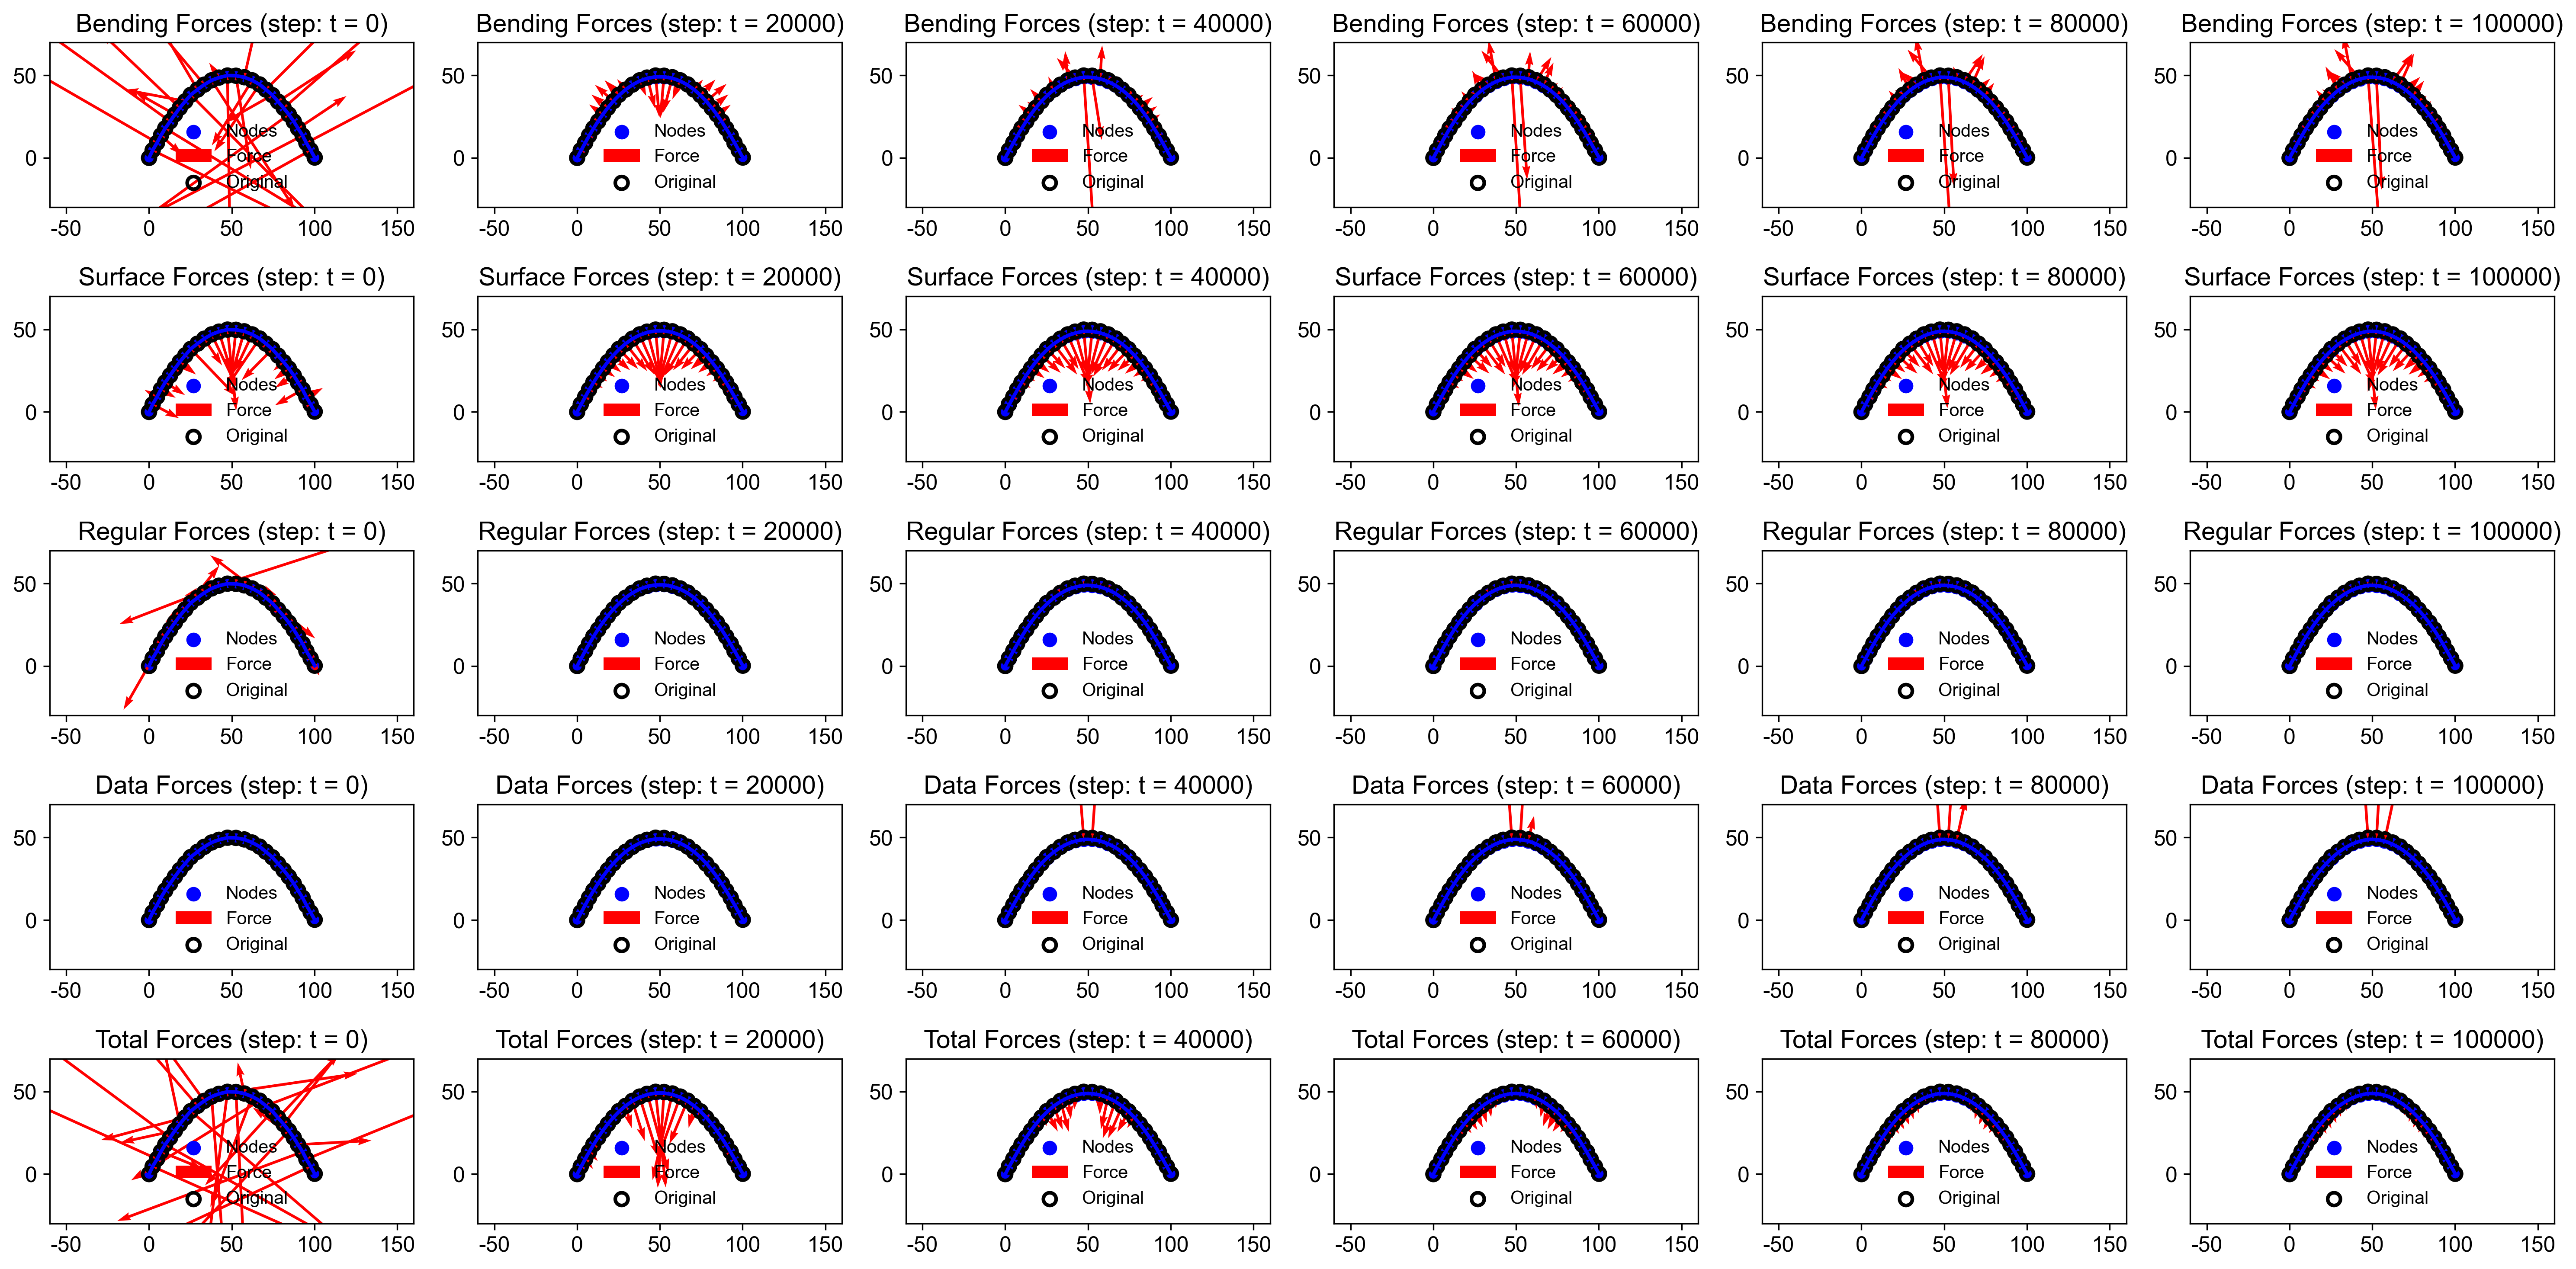

In [6]:
# Plot progress of the forward Euler

import matplotlib.pyplot as plt
import numpy as np
import os
from sample import plot_parabola_ax

N_node = 30
noise_level = 0.1
tot_iter = 1e5
del_show = 2e4
del_save = 1e3

interval = int(del_show/del_save)
n_show = int(tot_iter/del_show)+1
fig, axes = plt.subplots(5, n_show, figsize=(20, 10))

file_path = os.path.join(f"dat/data_fid_test", f"log_{N_node}_{noise_level:.2f}".replace('.', '') + f".npz")
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

for idx in range(0, n_show):

    n_iter = del_show * idx
    i = interval * idx
    total_forces = forces[i, 0] + forces[i, 1] + forces[i, 2] + forces[i, 3]
    
    plot_parabola_ax(coords[i], forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=100, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=100, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=100, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces", scale=100, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces", scale=100, ori_coords = ori_coords)

plt.tight_layout()
# plt.savefig(f"figures/spline_test/force_n{N_node}_{noise_level:.2f}".replace('.', '')+ f"_n{n_vertices:03d}_k{k_val}.png", dpi=300)
plt.show()


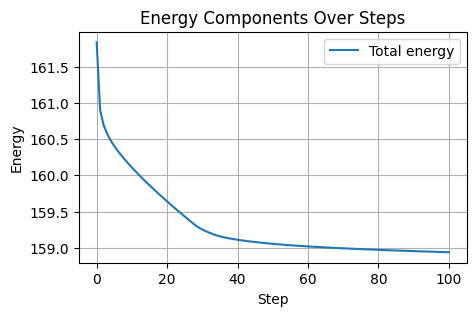

In [13]:
# Plotting energy state during forward Euler

import numpy as np
import matplotlib.pyplot as plt
import os

N_node = 30
noise_level = 0.1

file_path = os.path.join(f"dat/data_fid_test", f"log_{N_node}_{noise_level:.2f}".replace('.', '') + f".npz")
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

plt.figure(figsize=(5, 3))

energy_sum = energy.sum(axis=1)

# plt.plot(energy[:, 0], label=f'Bending energy')
# plt.plot(energy[:, 1], label=f'Surface energy')
# plt.plot(energy[:, 2], label=f'Regular energy')
# plt.plot(energy[:, 3], label=f'Datafid energy')

plt.plot(energy_sum, label=f'Total energy')

plt.title('Energy Components Over Steps')
plt.xlabel('Step')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)
plt.show()


## Image input

In [2]:
# setting spontaneous curvature (optional)

import numpy as np
from pathlib import Path
from coat_test import get_force_density
from plot import plot_coord_force, plot_coord_curve_force
from automembrane.energy import OpenPlaneCurveMaterial
from automembrane.geometry import OpenPlaneCurveGeometry

file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
N_node = 50
img_id = 1
file_path = os.path.join(f"dat/img_{img_id:02d}_{N_node}.npz")

# Load coordinates and compute curvature
data = np.load(file_path)
coords = data['coords']
coords = coords[-1]
curvature = OpenPlaneCurveGeometry.edge_curvature(coords)
spont_c = np.where(curvature < 0, curvature, 0)

# Threshold for segment length
threshold = 8  # Example threshold

# Step 2: Find the indices of non-zero values
non_zero_indices = np.where(spont_c != 0)[0]

# Step 3: Identify continuous segments of non-zero values
continuous_segments = np.split(non_zero_indices, np.where(np.diff(non_zero_indices) != 1)[0] + 1)

# Step 4: Filter out segments whose lengths are less than the threshold
filtered_spont_c = np.zeros_like(spont_c)  # Initialize with zeros
for segment in continuous_segments:
    if len(segment) >= threshold:
        filtered_spont_c[segment] = spont_c[segment]  # Keep segments that meet the length threshold

# Now, filtered_spont_c contains only the segments with lengths >= threshold
print(filtered_spont_c)

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -0.00378367 -0.00464475
 -0.00921239 -0.01124122 -0.02212562 -0.02543081 -0.01627631 -0.02374868
 -0.02127238 -0.0232576  -0.02524955 -0.03819423 -0.04195122 -0.02529692
 -0.01756467 -0.01079775 -0.0082175  -0.00725076 -0.00677715 -0.00994194
 -0.01085647 -0.00822513 -0.00523644  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]


In [3]:
from variation_relax import resample, relax_bending, relax_bending_log, preprocess_mesh
import os
import numpy as np
from pathlib import Path

N_node = 50

file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
ori_coords, _ = preprocess_mesh(file, resample_geometry=True, n_vertices=N_node)
spl_coords = ori_coords

params = {
    "Kb" : 1000,    # bending modulus
    "Ksg": 1,       # tension modulus
    "Ksl": 10,      # regularization term
    "Kdt": 100,     # data fidelity term
    # "dt": 1e-5,   # time step for forward Eulear
    "dt": 1e-4,     # time step for forward Eulear
    # "n_iter": int(8e2), # debug
    # "n_iter": 1,
    # "n_iter": int(1e4),   # total iteration of forward Eulear
    "n_iter": int(1e5),   # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition,
    "del_save": 1e3,
}

cvt = -0.02
spont_c = np.where(filtered_spont_c != 0, cvt, 0)

# Relax the curve by forward Eulear based on membrane energy
# coords, energy, forces = relax_bending_log(coords=spl_coords, data_points=ori_coords, **params)
coords, energy, forces = relax_bending_log(coords=spl_coords, data_points=ori_coords, spont_c=spont_c, **params)

# Storing data
file_path = os.path.join(f"dat/img_01_{N_node}.npz")
np.savez(file_path, ori_coords = ori_coords, coords = coords, energy=energy, forces=forces)


[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02
 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02 -0.02
 -0.02 -0.02 -0.02  0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.  ]


NameError: name 'exit' is not defined

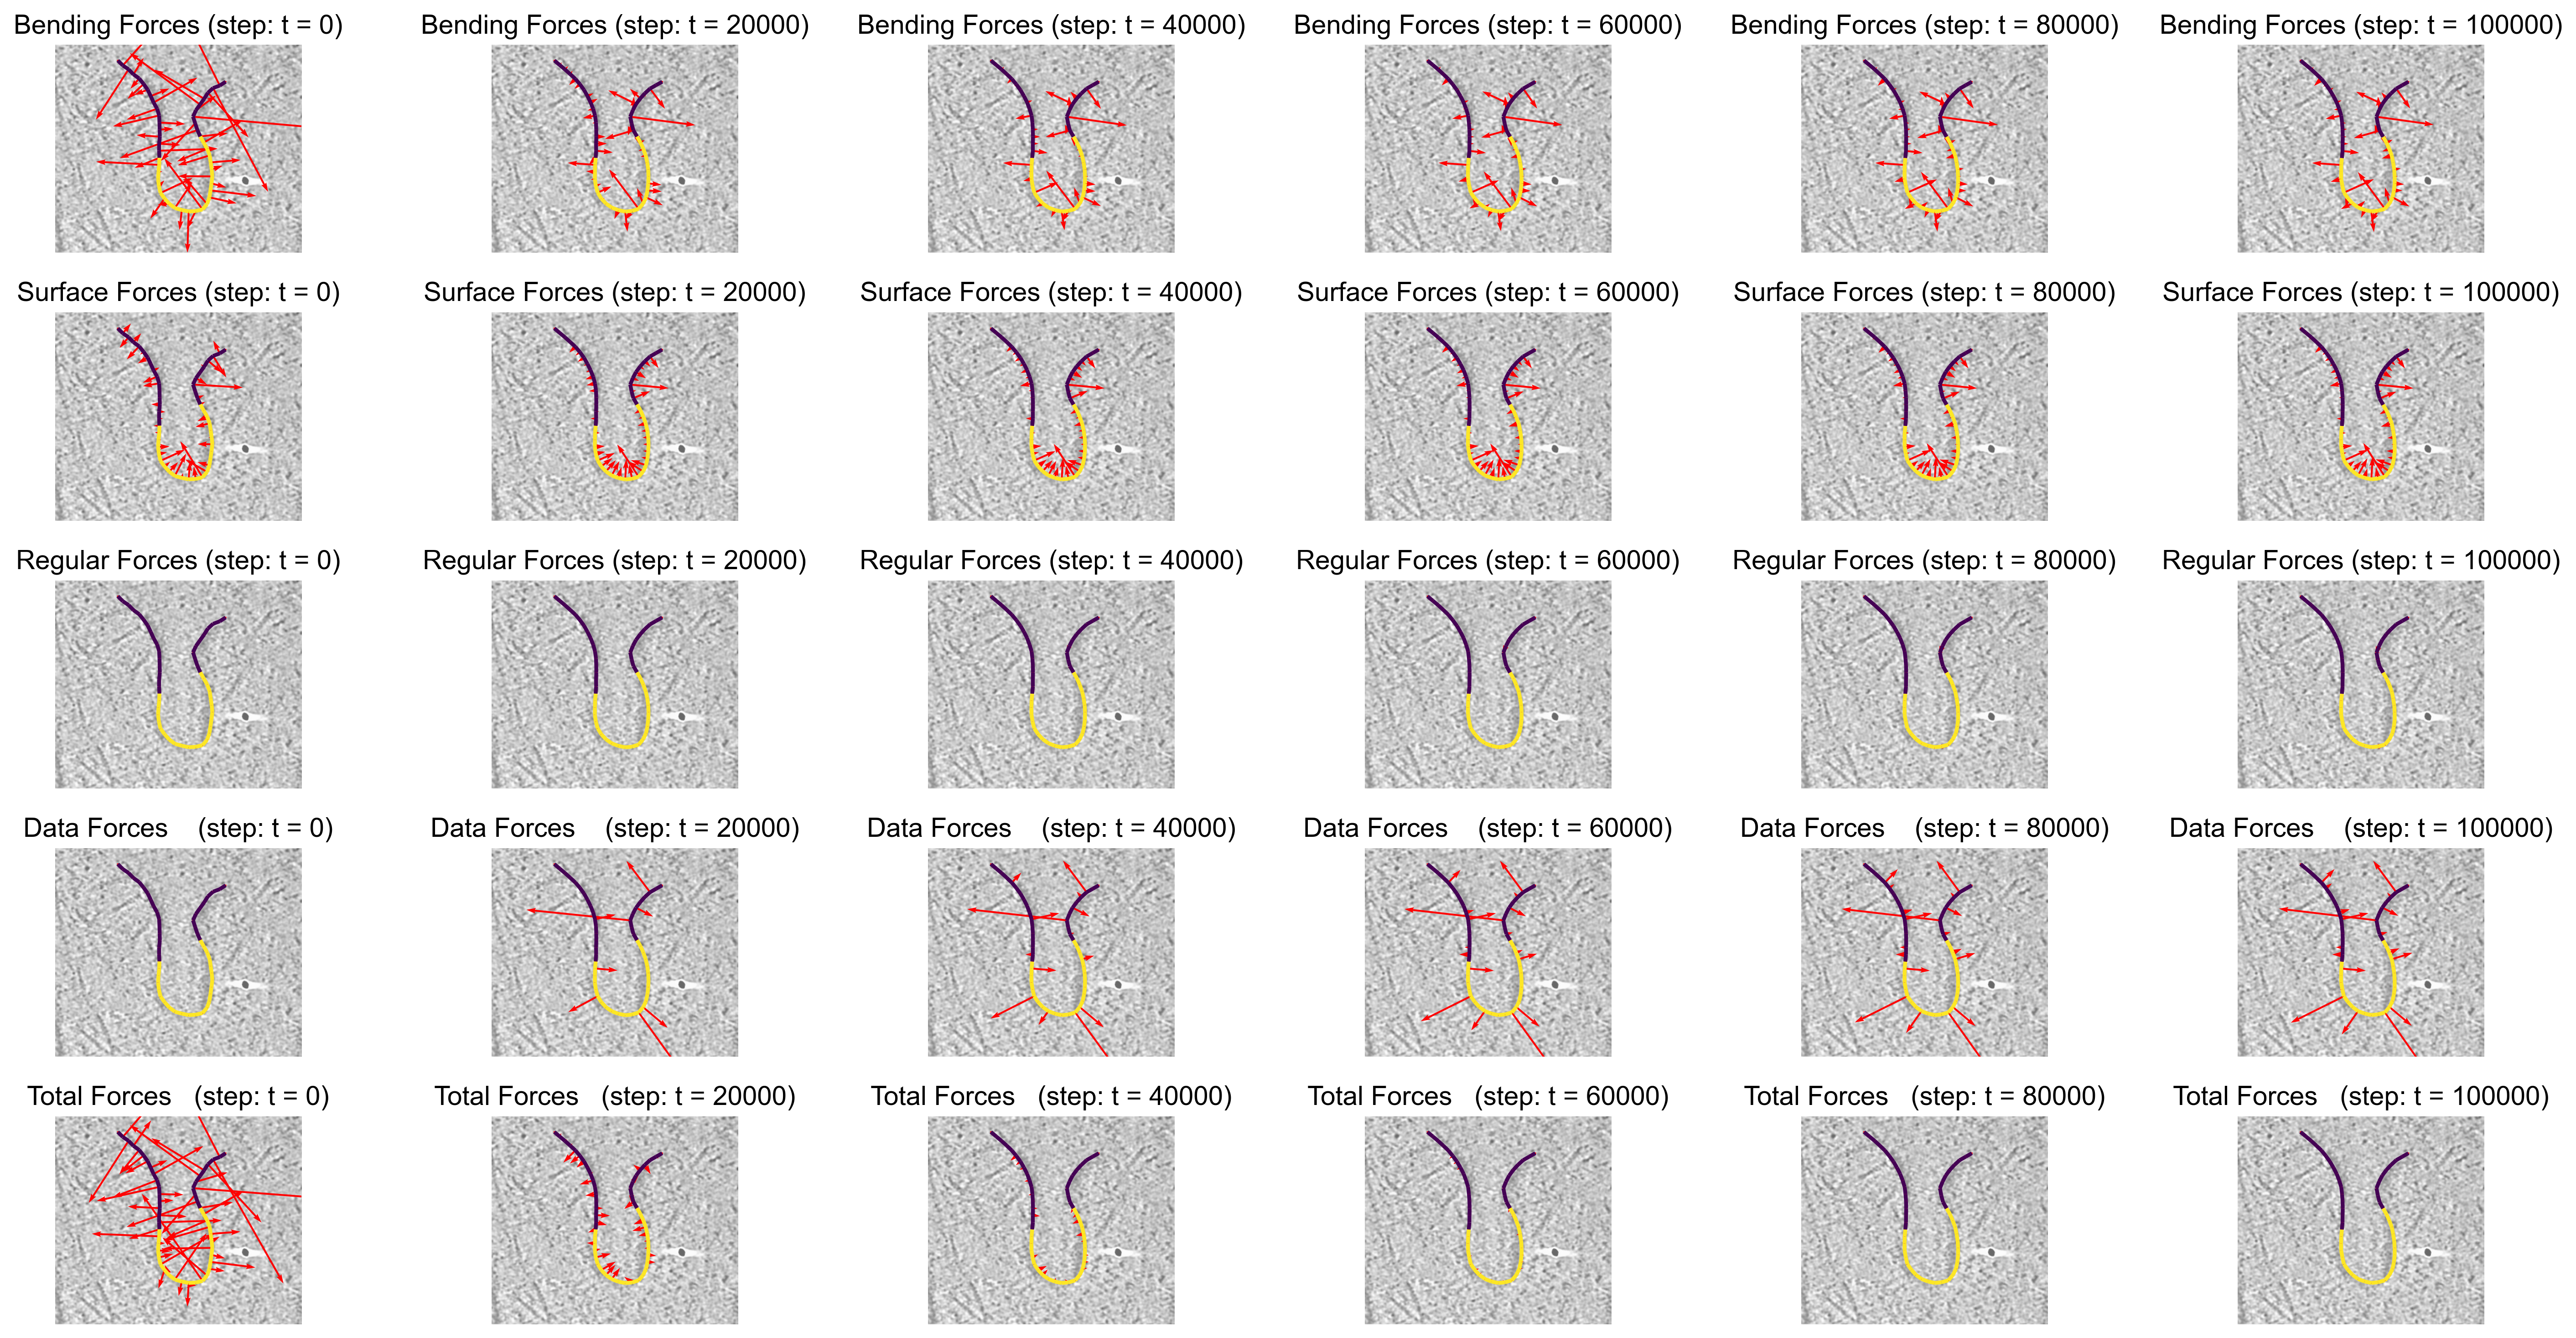

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from plot import plot_img_ax

file_stem = 'Membrane_2018June_Tomo26_CME_Invagination'
N_node = 50
img_id = 1
tot_iter = 1e5
del_show = 2e4
del_save = 1e3

interval = int(del_show/del_save)
n_show = int(tot_iter/del_show)+1
fig, axes = plt.subplots(5, n_show, figsize=(20, 10))

file_path = os.path.join(f"dat/img_{img_id:02d}_{N_node}.npz")
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

# curves = np.zeros(N_node)
curves = np.where(filtered_spont_c != 0, 1, 0)

for idx in range(0, n_show):

    n_iter = del_show * idx
    i = interval * idx
    total_forces = forces[i, 0] + forces[i, 1] + forces[i, 2] + forces[i, 3]
    
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces   ", scale=100, ori_coords = ori_coords)
    # plot_img_ax(file_stem, coords[i], curves, total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces  ", scale=100, ori_coords = ori_coords)

    plot_img_ax(file_stem, coords[i], curves, forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=100)
    plot_img_ax(file_stem, coords[i], curves, forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=100)
    plot_img_ax(file_stem, coords[i], curves, forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=100)
    plot_img_ax(file_stem, coords[i], curves, forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces   ", scale=100)
    plot_img_ax(file_stem, coords[i], curves, total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces  ", scale=100)


plt.tight_layout()
# plt.savefig(f"figures/spline_test/force_n{N_node}_{noise_level:.2f}".replace('.', '')+ f"_n{n_vertices:03d}_k{k_val}.png", dpi=300)
plt.show()


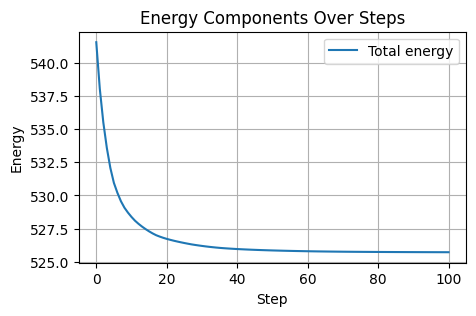

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

file_stem = 'Membrane_2018June_Tomo26_CME_Invagination'
N_node = 50
img_id = 1

file_path = os.path.join(f"dat/img_{img_id:02d}_{N_node}.npz")
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

plt.figure(figsize=(5, 3))

energy_sum = energy.sum(axis=1)

# plt.plot(energy[:, 0], label=f'Bending energy')
# plt.plot(energy[:, 1], label=f'Surface energy')
# plt.plot(energy[:, 2], label=f'Regular energy')
# plt.plot(energy[:, 3], label=f'Datafid energy')

plt.plot(energy_sum, label=f'Total energy')

plt.title('Energy Components Over Steps')
plt.xlabel('Step')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
energy_sum = [energy[:, i].sum() for i in range(4)]

In [10]:
print(energy[:,0])

[43.41459487 40.56730051 38.54911201 37.06362459 35.9299414  35.10312364
 34.56427155 34.11781952 33.77432338 33.51231277 33.28771619 33.09274973
 32.93394794 32.79520282 32.67259005 32.56338602 32.46878497 32.39404787
 32.33320499 32.27937993 32.23248026 32.19175609 32.15432178 32.12002021
 32.08820426 32.05851088 32.03071334 32.0046167  31.98272472 31.96296645
 31.94467801 31.92771991 31.91243825 31.89886453 31.88627239 31.87519688
 31.86522002 31.85530855 31.84605239 31.83738476 31.82924717 31.82164007
 31.81449968 31.80776297 31.80139386 31.7953602  31.78963328 31.7841874
 31.77899952 31.77404897 31.7693171  31.76478715 31.76044396 31.75627382
 31.75226432 31.74840419 31.74468319 31.741092   31.73762211 31.73426577
 31.73101587 31.72786589 31.72480989 31.72184825 31.71905098 31.71633971
 31.71370684 31.71114597 31.70865147 31.70621831 31.70384201 31.70181099
 31.70016322 31.69859329 31.69721068 31.69607055 31.69500493 31.69400772
 31.69307343 31.6921971  31.69137422 31.69060074 31.